# 18. Additional analyses for the revision

## Setup

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from tqdm import tqdm

from convergence.plotting import plot_faverage_parcelation
from convergence.power_law import fit_powerlaw_zero_with_bootstrap
from convergence.figures import plot_cbar
from convergence.figures import setup_matplotlib_fonts

setup_matplotlib_fonts()

In [93]:
derivatives_folder = Path("derivatives/")
figures_folder = Path("figures")
output_folder = Path("figures/18_revision")
output_folder.mkdir(exist_ok=True, parents=True)
filename_hcp = derivatives_folder / "metadata/hcp.csv"

## Reviewer 1. Comment 4 (Influence of Roi size)

Reliability analysis and influence of ROI size

In [329]:
filename_voxel_count = derivatives_folder / "revision/roi_dims.parquet"
filename_repetitions = derivatives_folder / "revision/rsa_reliability_isrsa.42-all-subjects.parquet"
#filename_repetitions = derivatives_folder / "revision/rsa_reliability_isrsa_repetition_based-50.parquet"

hcp = pd.read_csv(filename_hcp)
hcp = hcp[["roi", "name", "mne_name", "area_id", "area_color", "area"]]
hcp

# 1000 repetitions with splits with half of the stimuli
df = pd.read_parquet(filename_repetitions).query("subject_i != subject_j")
display(df.head()) # roi, subset, subset_size, similarity, subject_i, subject_j

# Groupby roi, and repetition (subset). Compute mean similarity
df_repetitions = df.groupby(["roi", "subset"]).aggregate({"similarity": "mean"}).reset_index()
# Aggregate across repetitions: mean and std
df = df_repetitions.groupby(["roi"]).similarity.describe().reset_index()[['roi', "mean", "std"]]
# Add roi and voxel information
df = df.merge(hcp, on="roi")
voxel_count = pd.read_parquet(filename_voxel_count).rename(columns={"n_voxels": "voxel_count"})
voxel_count = voxel_count.groupby("roi").aggregate({"voxel_count": "mean"}).reset_index()
voxel_count = voxel_count.merge(hcp, on='roi').groupby("name").voxel_count.sum().reset_index()
voxel_count = voxel_count.merge(hcp.query("roi <= 180")[["name", "roi"]], on="name")
voxel_count = voxel_count[["roi", "voxel_count"]].sort_values("roi").reset_index(drop=True)

df_repetitions = df_repetitions.merge(hcp, on="roi")

# Full comparison - main analisys
filename_full_comparison = derivatives_folder / "nsd/rsa_subject_subject_alignment_shift_1_joined.parquet"
df_full = pd.read_parquet(filename_full_comparison)
df_full = df_full.query("roi_x == roi_y and subject_i != subject_j")
df_full = df_full.groupby(["roi_x"]).similarity.mean().reset_index()
df_full = df_full.rename(columns={"roi_x": "roi"})
df_full = df_full.merge(hcp, on="roi")



df = df.merge(voxel_count, on="roi")
df["relative_error"] = df["std"] / df["mean"]
df["snr"] = (df["mean"]**2) / (df["std"]**2 + df["mean"]**2)
df.sort_values("std", ascending=False).head() 

,roi,subset,subset_size,similarity,subject_i,subject_j
180000,1,0,1500,0.330385,1,2
180001,1,1,1500,0.336144,1,2
180002,1,2,1500,0.313831,1,2
180003,1,3,1500,0.333106,1,2
180004,1,4,1500,0.302579,1,2


,roi,mean,std,name,mne_name,area_id,area_color,area,voxel_count,relative_error,snr
3,4,0.177583,0.011964,V2,L_V2_ROI-lh,1,#aec7e8,Early Visual (V2-4),14275.250,0.067372,0.995482
0,1,0.194255,0.011882,V1,L_V1_ROI-lh,0,#1f77b4,Primary Visual,19820.875,0.061169,0.996272
159,160,0.212979,0.010320,VMV2,L_VMV2_ROI-lh,2,#ff7f0e,Ventral Visual,1236.500,0.048453,0.997658
1,2,0.210761,0.009743,MST,L_MST_ROI-lh,6,#2ca02c,MT+ Visual Areas,1488.500,0.046228,0.997867
152,153,0.184579,0.009383,VMV1,L_VMV1_ROI-lh,2,#ff7f0e,Ventral Visual,1564.875,0.050833,0.997423


Figure for revision and supplementary

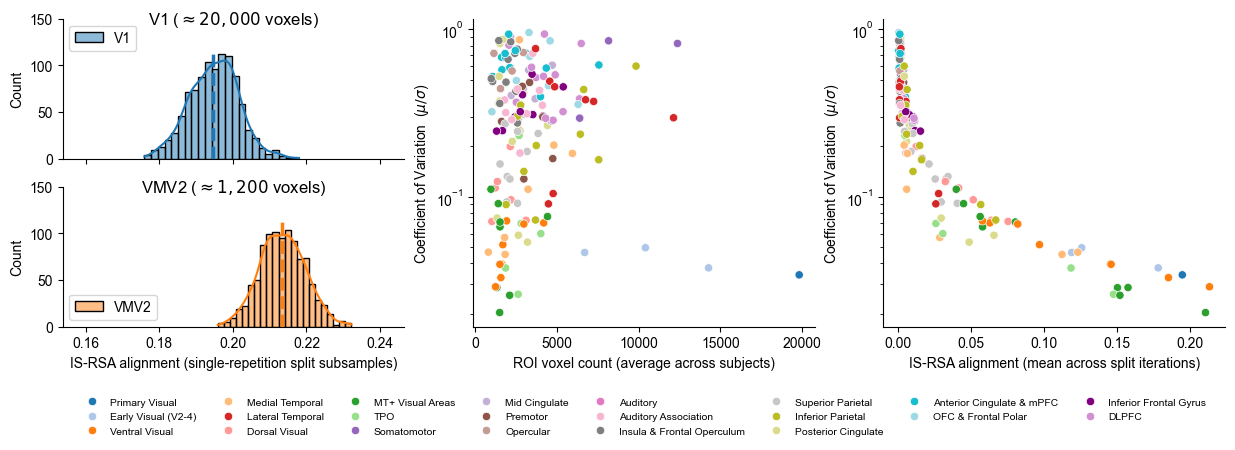

In [323]:
# Legend information
palette = df[["area", "area_color"]].drop_duplicates().set_index("area")["area_color"].to_dict()
name_palette = (
    df[["name", "area_color"]].drop_duplicates().set_index("name")["area_color"].to_dict()
)
hue_order = df.sort_values(["area_id"]).area.unique()


fig, axes = plt.subplot_mosaic("ACD\nBCD", figsize=(3 * 5, 4))
ax1 = axes["A"]
ax1b = axes["B"]
ax2 = axes["C"]
ax3 = axes["D"]

ylim = -0.0005, 0.008
#ylim = -0.0005, 0.013
labels = ["V1", "V2", "V3", "V4", "VMV2", "MST"]
hist_rois = ["V1", "VMV2"]

xmin = df_repetitions.query("name in @hist_rois").similarity.min()
xmax = df_repetitions.query("name in @hist_rois").similarity.max()

xmin, xmax = 0.15369757517640079, 0.24661774880119733
for ax, roi_name in zip((ax1, ax1b), hist_rois):
    sns.despine(ax=ax)
    sns.histplot(
        data=df_repetitions.query("name in @roi_name"),
        x="similarity",
        hue="name",
        #bins=20,
        palette=name_palette,
        ax=ax,
        kde=True,
    )
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, 150)
    sns.move_legend(ax, title="", loc="upper left")
ax1b.set_xlabel("IS-RSA alignment (single-repetition split subsamples)")

sns.scatterplot(
    data=df.query("snr > 0.5"),
    x="voxel_count",
    y="relative_error",
    hue="area",
    palette=palette,
    hue_order=hue_order,
    legend=True,
    ax=ax2,
)
sns.despine(ax=ax2)
ax2.legend(
    title="", bbox_to_anchor=(0.5, -0.2), loc="upper center", ncol=8, frameon=False, fontsize=7.5
)

ax2.set_xlabel("ROI voxel count (average across subjects)")
ax2.set_ylabel("Half-split IS-RSA standard deviation")
#ax2.set_ylim(ylim)
#ax2.ticklabel_format(axis="y", style="sci", scilimits=(-3, -3))
#ax2.ticklabel_format(axis="y", style="sci", scilimits=(-2, -2))


sns.scatterplot(
    data=df.query("snr > 0.5"),
    x="mean",
    y="relative_error",
    hue="area",
    palette=palette,
    hue_order=hue_order,
    legend=False,
    ax=ax3,
)
sns.despine(ax=ax3)
#ax3.set_ylim(ylim)
ax3.set_xlabel("IS-RSA alignment (mean across split iterations)")
ax3.set_ylabel("Half-split IS-RSA standard deviation")


adjustments1 = {
    'MST': (1000, -0.0005),
}

adjustments2 = {
    'VMV2': (-0.01, 0),
    'MST': (0, -0.001),
}

# # Add mentioned labels text
# for _, row in df.query("name in @labels").iterrows():

#     x, y = adjustments1.get(row["name"], (0, 0))

#     ax2.text(
#         row["voxel_count"] + x,
#         row["relative_error"] + 0.0005 + y,
#         row["name"],
#         color=(0.24, 0.24, 0.24),
#         fontsize=9,
#         ha="center",
#     )

#     x, y = adjustments2.get(row["name"], (0, 0))
#     ax3.text(
#         row["mean"] + x,
#         row["relative_error"] + 0.0005 + y,
#         row["name"],
#         color=(0.24, 0.24, 0.24),
#         fontsize=9,
#         ha="center",
#     )


# x_min = df["mean"].min()
# x_fit, y_fit, y_lower, y_upper, r2, params = fit_powerlaw_zero_with_bootstrap(
#     df["mean"] - x_min, df["std"], n_boot=1000
# )
# x_fit = x_fit + x_min

# adjustment_label = f"$y={params[0]:.3f} x^{{{params[1]:.2f}}}$"
# ax3.plot(x_fit, y_fit, color="maroon", linestyle="--", label=adjustment_label, zorder=-50)
# ax3.fill_between(x_fit, y_lower, y_upper, color="maroon", alpha=0.2, zorder=-100)
# ax3.legend(loc="lower right")
#ax3.ticklabel_format(axis="y", style="sci", scilimits=(-2, -2))
#ax3.ticklabel_format(axis="y", style="sci", scilimits=(-3, -3))


v1_mean_similarity = df_full.query("name == 'V1'").similarity.values[0]
ax1.axvline(v1_mean_similarity, ymin=0, ymax=0.75, zorder=100, color="blue", lw=2.5, c='C0', ls='--', label="V1 full set")


vmv2_mean_similarity = df_full.query("name == 'VMV2'").similarity.values[0]
ax1b.axvline(vmv2_mean_similarity, ymin=0, ymax=0.75, zorder=100, color="blue", lw=2.5, c='C1', ls='--' , label="V1 full set")

ax1.set_title(r"V1 ($\approx 20,000$ voxels)", y=0.9)
ax1.set_xticklabels([])

ax1b.set_title(r"VMV2 ($\approx 1,200$ voxels)", y=0.9)
sns.move_legend(ax1b, title="", loc="lower left")

# Set log yscale of ax2 and ax3
ax2.set_yscale("log")
ax3.set_yscale("log")


ax2.set_ylabel("Coefficient of Variation  ($\\mu / \\sigma$)")
ax3.set_ylabel("Coefficient of Variation  ($\\mu / \\sigma$)")

# fig.suptitle("IS-RSA reliability: stimuli generalization")
# ax3 scale loglog
#fig.savefig(output_folder / "reviewer2-comment4-stimulus-generalization.pdf", transparent=True, bbox_inches="tight")
#fig.savefig(output_folder / "reviewer2-comment4-stimulus-generalization.svg", transparent=True, bbox_inches="tight")

fig.savefig(output_folder / "reviewer2-comment4-trial-repetition.pdf", transparent=True, bbox_inches="tight")
fig.savefig(output_folder / "reviewer2-comment4-trial-repetition.svg", transparent=True, bbox_inches="tight")

### Posthoc correction 

Control for similarity ~ C(roi) + log(Voxel count) + (1|subject)


In [ ]:
df_full = pd.read_parquet(filename_full_comparison)
df_full = df_full.query("roi_x == roi_y and subject_i != subject_j")
df_voxel_count = pd.read_parquet(filename_voxel_count).rename(columns={"n_voxels": "voxel_count"})
# Where roi > 180, substract 180
df_voxel_count.loc[df_voxel_count.roi > 180, "roi"] -= 180
df_voxel_count = df_voxel_count.groupby(["roi", "subject"]).aggregate({"voxel_count": "sum"}).reset_index()


df_full = df_full[["roi_x", "similarity", "subject_i", "subject_j"]].rename(columns={"roi_x": "roi"})
df_full = df_full.merge(df_voxel_count, left_on=["roi", "subject_i"], right_on=["roi", "subject"])
df_full = df_full.rename(columns={"voxel_count": "voxel_count_i"}).drop(columns=["subject"])
df_full = df_full.merge(df_voxel_count, left_on=["roi", "subject_j"], right_on=["roi", "subject"])
df_full = df_full.rename(columns={"voxel_count": "voxel_count_j"}).drop(columns=["subject"])
# Take the mean as voxel count
df_full["voxel_count"] = (df_full["voxel_count_i"] + df_full["voxel_count_j"]) / 2
df_full = df_full[["roi", "subject_i", "subject_j", "similarity", "voxel_count"]]
df_full = df_full.groupby(["roi", "subject_i"]).aggregate({"similarity": "mean", "voxel_count": "mean"}).reset_index()
df_full = df_full.rename(columns={"subject_i": "subject"})

df = df_full.copy()

# Try with log voxel count following a saturation curve
df["voxel_count"] = np.log(df["voxel_count"])

md = smf.mixedlm("similarity ~ C(roi) + voxel_count", 
                 data=df, 
                 groups=df["subject"])
mdf = md.fit()

print(mdf.summary())

# Extract the beta coefficient for voxel_count
# This value represents: "For every 1 voxel added, RSA changes by X"
beta_size = mdf.params['voxel_count']
print(f"\nSize Coefficient (beta): {beta_size:.8f}")

# Formula: Adjusted = Original - (beta * Size)
mean_voxel_count = df['voxel_count'].mean()

df['similarity_corrected'] = df['similarity'] - (beta_size * (df['voxel_count'] - mean_voxel_count))


          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: similarity
No. Observations:  1440    Method:             REML      
No. Groups:        8       Scale:              0.0001    
Min. group size:   180     Log-Likelihood:     3610.8045 
Max. group size:   180     Converged:          Yes       
Mean group size:   180.0                                 
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      0.124    0.056   2.231 0.026  0.015  0.234
C(roi)[T.2]    0.035    0.016   2.209 0.027  0.004  0.065
C(roi)[T.3]   -0.166    0.014 -12.057 0.000 -0.194 -0.139
C(roi)[T.4]   -0.014    0.006  -2.315 0.021 -0.026 -0.002
C(roi)[T.5]   -0.064    0.007  -9.348 0.000 -0.078 -0.051
C(roi)[T.6]   -0.068    0.008  -8.047 0.000 -0.085 -0.052
C(roi)[T.7]   -0.080    0.015  -5.328 0.000 -0.110 -0.051
C(roi)[T.8]   -0.190    

/Users/pablomm/Desktop/Paper Convergent Transformations/deep-convergence/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Plot corrected vs uncorrected similarities

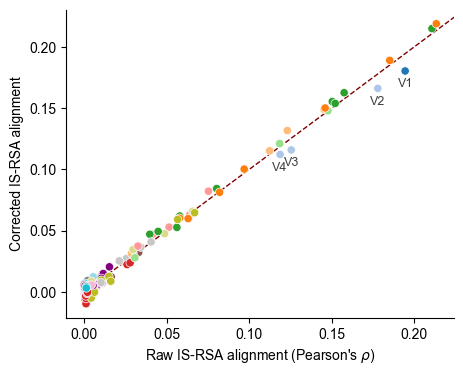

In [501]:

fig, ax = plt.subplots(figsize=(5,4))

df_corrected = df.groupby(["roi"]).aggregate({"similarity_corrected": "mean", "similarity": "mean"}).reset_index()
df_corrected = df_corrected.merge(hcp, on="roi")
palette = df_corrected[["area", "area_color"]].drop_duplicates().set_index("area")["area_color"].to_dict()
hue_order = df_corrected.sort_values("area_id").area.unique()

sns.scatterplot(data=df_corrected, x="similarity", y="similarity_corrected", hue="area", legend=False, palette=palette, hue_order=hue_order, ax=ax)

labels = ["V1", "V2", "V3", "V4"]
for _, row in df_corrected.query("name in @labels").iterrows():
    ax.text(
        row["similarity"],
        row["similarity_corrected"] -0.013,
        row["name"],
        color=(0.24, 0.24, 0.24),
        fontsize=9,
        ha="center",
    )
# Fix the lim
ax.set_xlim(ax.get_xlim())
ax.set_ylim(ax.get_ylim())
ax.plot([0, 1], [0, 1], zorder=-1000, color='maroon', linestyle='--', lw=1)
ax.set_xlabel("Raw IS-RSA alignment (Pearson's $\\rho$)")
ax.set_ylabel("Corrected IS-RSA alignment")
sns.despine(ax=ax)
fig.savefig(output_folder / "reviewer2-comment4-voxel-correction.pdf", transparent=True, bbox_inches="tight")

Distribution of log(voxel count) per ROI. More "normal" after log transform.

<Axes: ylabel='Frequency'>

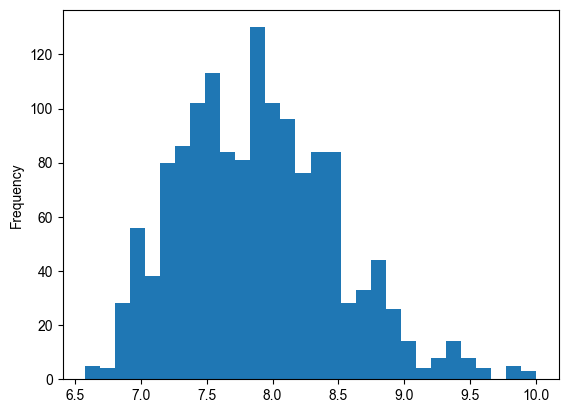

In [509]:
df.voxel_count.plot.hist(bins=30)

Similarity corrected vs uncorrected with same scale

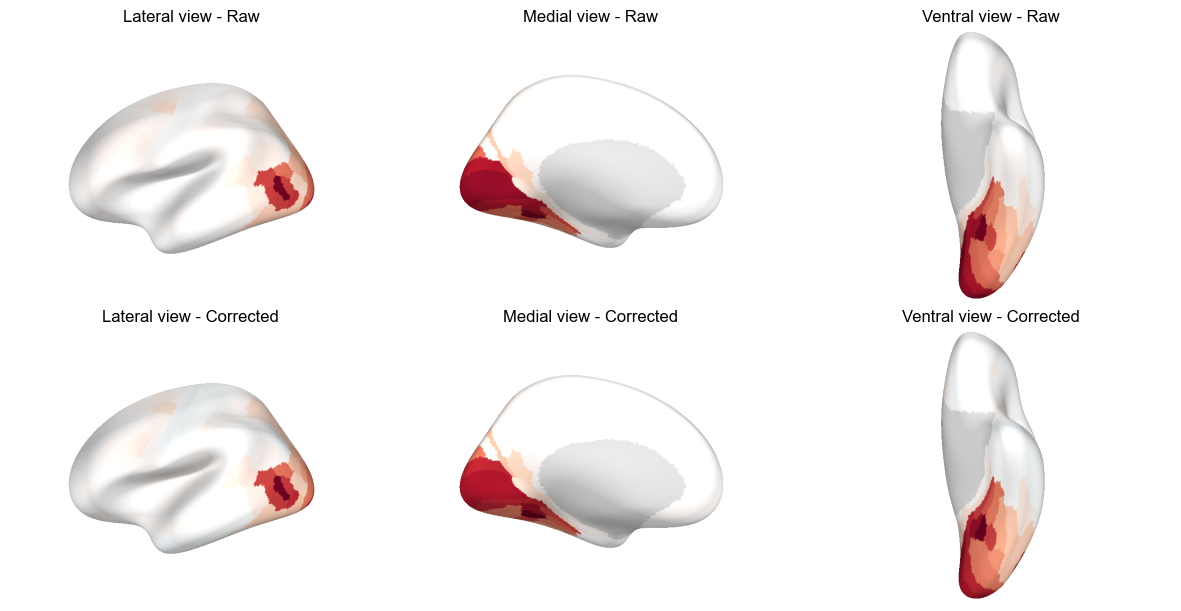

In [502]:
vmax = max(df_corrected.similarity.max(), df_corrected.similarity_corrected.max())
normalize=(-vmax, vmax)
views = ["lateral", "medial", "ventral"]

for column in ["similarity", "similarity_corrected"]:
    brain = plot_faverage_parcelation(
        df_corrected,
        value_column=column,
        normalize=normalize,
        default_color="lightgrey",
        default_value=None,
        cmap="RdBu_r",
        hemisphere="lh",
        )
    for view in views:
        brain.show_view(view)
        brain.save_image(output_folder / f"reviewer2-comment4-voxel-correction-lh-{view}-{column}.png", mode="rgba")
    brain.close()

# Show a preview
fig, axes = plt.subplots(2, 3, figsize=(3 * 4, 2 * 3), constrained_layout=True)
for i, column in enumerate(["similarity", "similarity_corrected"]):
    for j, view in enumerate(views):
        ax = axes[i, j]
        img = plt.imread(output_folder / f"reviewer2-comment4-voxel-correction-lh-{view}-{column}.png")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{view.capitalize()} view - {'Corrected' if column=='similarity_corrected' else 'Raw'}")


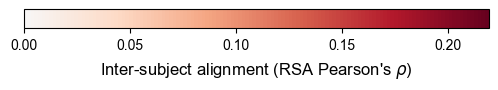

In [504]:
fig_cbar, ax_cbar = plot_cbar(
    cmap="RdBu_r",
    title=r"Inter-subject alignment (RSA Pearson's $\rho$)",
    vmin=-vmax,
    vmax=vmax,
    locator=0.05,
    horizontal=True,
    rotation=0,
    labelpad=5,
    figsize=(6, 0.25),
    percent=False,
)
ax_cbar.set_xlim(0, vmax)
fig_cbar.savefig(output_folder / "reviewer2-comment4-voxel-correction-cbar.pdf", transparent=True, bbox_inches="tight")

## Reviewer 1. Comment 5 (MPnet alignment)

In [7]:

revision_folder = derivatives_folder / "revision"
files = [
    "sentence-transformers-all-mpnet-base-v2-avg_prompt-coco_subject-model-nsd-mpnet.parquet", # Last layer. Extracted via sentence-transformers
    "sentence-transformers-mpnet-internal-layers-coco-avg_subject-model-nsd-mpnet.parquet", # Internal layers. Avg prompt
]

df_last = pd.read_parquet(revision_folder / files[0]) # Should be equal to the last layer of all the internal layers
df = pd.read_parquet(revision_folder / files[1])

hcp = pd.read_csv(filename_hcp)

Last layer MPnet (as extracted in Doerig et al. 2025) with our methodology

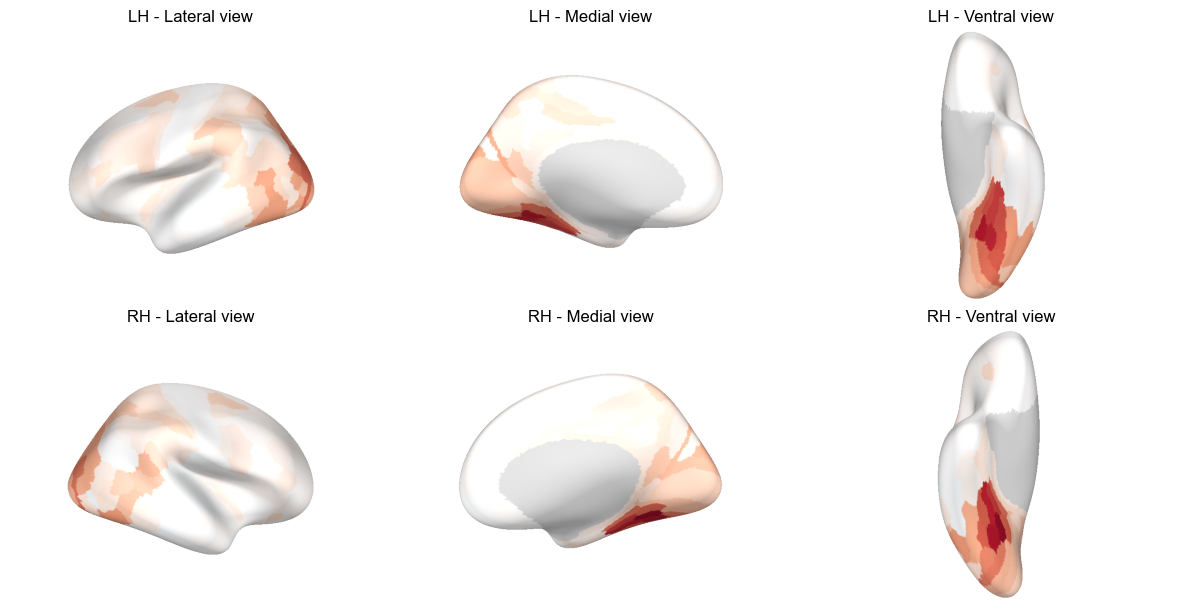

In [8]:
df_last_g = df_last.groupby(["roi"]).similarity.mean().reset_index()
df_last_g = df_last_g.merge(hcp, on="roi")

# print(df_last_g.similarity.max(), df_last_g.similarity.min()) # (-0.004, 0.08)
vmax = df_last_g.similarity.max()


for scale in [0.1, 0.22]:
    normalize = (-scale, scale)

    views = ["lateral", "medial", "ventral"]
    for hemisphere in ["lh", "rh"]:
        brain = plot_faverage_parcelation(
            df_last_g,
            value_column="similarity",
            normalize=normalize,
            default_color="lightgrey",
            default_value=None,
            cmap="RdBu_r",
            hemisphere=hemisphere,
        )
        for view in views:
            brain.show_view(view)
            brain.save_image(output_folder / f"reviewer2-comment5-last-layer-{hemisphere}-{view}-{scale:.2f}.png", mode="rgba")

        brain.close()

# Show a preview
scale = 0.1
fig, axes = plt.subplots(2, 3, figsize=(3 * 4, 2 * 3), constrained_layout=True)
for i, hemisphere in enumerate(["lh", "rh"]):
    for j, view in enumerate(views):
        ax = axes[i, j]
        img = plt.imread(output_folder / f"reviewer2-comment5-last-layer-{hemisphere}-{view}-{scale:.2f}.png")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{hemisphere.upper()} - {view.capitalize()} view");

In [ ]:
df_g = df.groupby(["roi", "layer"]).similarity.mean().reset_index()
df_g = df_g.merge(hcp[["roi", "name", "mne_name", "area_id", "area", "area_color"]], on="roi")
df_g

# # print(df_last_g.similarity.max(), df_last_g.similarity.min()) # (-0.004, 0.08)
# vmax = df_last_g.similarity.max()

scale = 0.22
normalize = (-scale, scale)
views = ["lateral", "medial", "ventral"]

for layer in tqdm(df_g.layer.unique()):    
    for hemisphere in ["lh", "rh"]:
        brain = plot_faverage_parcelation(
            df_g.query("layer == @layer"),
            value_column="similarity",
            normalize=normalize,
            default_color="lightgrey",
            default_value=None,
            cmap="RdBu_r",
            hemisphere=hemisphere,
        )
        for view in views:
            brain.show_view(view)
            brain.save_image(output_folder / f"reviewer2-comment5-layer-{layer}-{hemisphere}-{view}-{scale:.2f}.png", mode="rgba")

        brain.close()

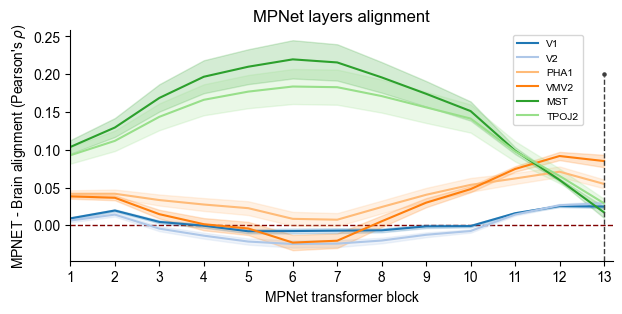

In [81]:

rois = ["V1", "V2", "PHA1", "VMV2", "MST", "TPOJ2"]
cluster = {
    "V1": "Visual Cortex",
    "V2": "Visual Cortex",
    "PHA1": "Ventral Hub",
    "VMV2": "Ventral Hub",
    "MST": "LOTC Hub",
    "TPOJ2": "LOTC Hub",
}

palette = hcp[["name", "area_color"]].drop_duplicates().set_index("name")["area_color"].to_dict()

df_g = df.groupby(["roi", "layer", "subject"]).similarity.mean().reset_index().copy()
# WHere roi > 180, substract 180
df_g.loc[df_g.roi > 180, "roi"] -= 180
df_g = df_g.groupby(["roi", "layer", "subject"]).similarity.mean().reset_index().copy()
df_g["layer"] += 1
df_g = df_g.merge(hcp[["roi", "name", "mne_name", "area_id", "area", "area_color"]], on="roi")
df_subplot = df_g.query("name in @rois").copy()
# Add cluster information
df_subplot["cluster"] = df_subplot["name"].map(cluster)

fig, ax = plt.subplots(figsize=(7, 3))
sns.lineplot(data=df_subplot, x="layer", y="similarity", hue="name", palette=palette, hue_order=rois, ax=ax, errorbar='se')
sns.despine(ax=ax)
# Move legend
ax.legend(title="", bbox_to_anchor=(0.88, 1), loc="upper center", ncol=1, fontsize=7.5)
ax.set_xlim(1, 13.2)
ax.set_ylabel("MPNET - Brain alignment (Pearson's $\\rho$)")
ax.axhline(0, color='maroon', linestyle='--', lw=1, zorder=-100)
ax.set_title("MPNet layers alignment")
# Set all layers in xticks
ax.set_xticks(df_subplot.layer.unique())
ax.set_xlabel("MPNet transformer block")

# Add a vertical line at layer 12
ax.axvline(13, ymax=0.8, color=(0.24, 0.24, 0.24), linestyle='--', lw=1)
ax.scatter(13, 0.2, color=(0.24, 0.24, 0.24), s=5)
fig.savefig(output_folder / "reviewer2-comment5-mpnet-layers-alignment.pdf", transparent=True, bbox_inches="tight")

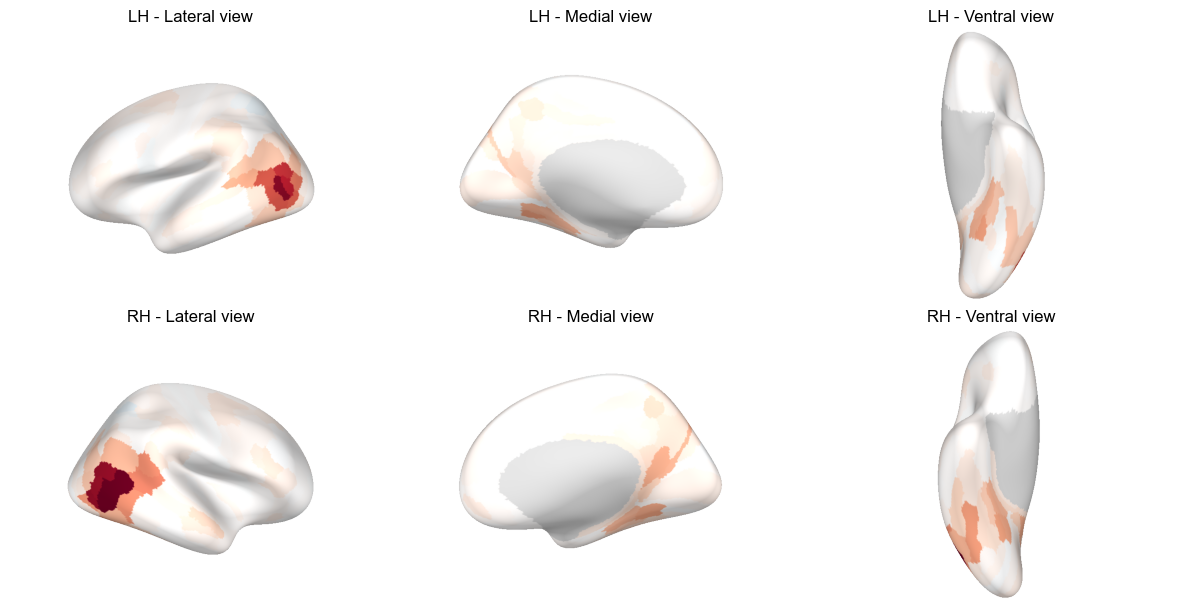

In [38]:
df_max = df.copy()
df_max["abs_similarity"] = df_max["similarity"].abs()
df_max = df_max.sort_values("abs_similarity", ascending=False)
df_max = df_max.groupby(["roi", "session", "subject"]).first().reset_index()
df_max = df_max.groupby(["roi"]).similarity.mean().reset_index()
df_max = df_max.merge(hcp, on="roi")



views = ["lateral", "medial", "ventral"]
normalize = (-0.22, 0.22)
hemispheres = ["lh", "rh"]
for hemisphere in hemispheres:
    brain = plot_faverage_parcelation(
        df_max,
        value_column="similarity",
        normalize=normalize,
        default_color="lightgrey",
        default_value=None,
        cmap="RdBu_r",
        hemisphere=hemisphere,
    )
    for view in views:
        brain.show_view(view)
        brain.save_image(output_folder / f"reviewer2-comment5-max-layer-{hemisphere}-{view}-0.22.png", mode="rgba")

    brain.close()

# Show a preview
fig, axes = plt.subplots(2, 3, figsize=(3 * 4, 2 * 3), constrained_layout=True)
for i, hemisphere in enumerate(hemispheres):
    for j, view in enumerate(views):
        ax = axes[i, j]
        img = plt.imread(output_folder / f"reviewer2-comment5-max-layer-{hemisphere}-{view}-0.22.png")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{hemisphere.upper()} - {view.capitalize()} view");

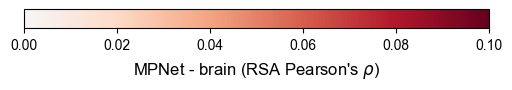

In [88]:
fig_cbar, ax_cbar = plot_cbar(
cmap="RdBu_r",
title=r"MPNet - brain (RSA Pearson's $\rho$)",
vmin=-0.1,
vmax=0.1,
locator=0.02,
horizontal=True,
rotation=0,
labelpad=5,
figsize=(6, 0.25),
percent=False,
)
ax_cbar.set_xlim(0, 0.1)
fig_cbar.savefig(output_folder / "reviewer2-comment5-last-layer-cbar.pdf", transparent=True, bbox_inches="tight")

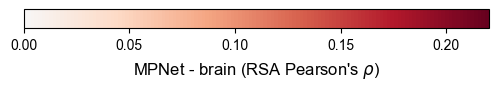

In [90]:
fig_cbar, ax_cbar = plot_cbar(
cmap="RdBu_r",
title=r"MPNet - brain (RSA Pearson's $\rho$)",
vmin=-0.22,
vmax=0.22,
locator=0.05,
horizontal=True,
rotation=0,
labelpad=5,
figsize=(6, 0.25),
percent=False,
)
ax_cbar.set_xlim(0, 0.22)
fig_cbar.savefig(output_folder / "reviewer2-comment5-max-layer-cbar.pdf", transparent=True, bbox_inches="tight")

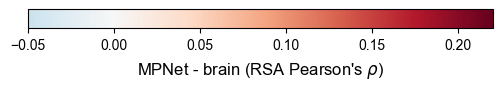

In [321]:
fig_cbar, ax_cbar = plot_cbar(
cmap="RdBu_r",
title=r"MPNet - brain (RSA Pearson's $\rho$)",
vmin=-0.22,
vmax=0.22,
locator=0.05,
horizontal=True,
rotation=0,
labelpad=5,
figsize=(6, 0.25),
percent=False,
)
ax_cbar.set_xlim(-0.05, 0.22)
fig_cbar.savefig(output_folder / "reviewer2-comment5-max-layer-cbar-miniature.pdf", transparent=True, bbox_inches="tight")

## Reviewer 2. Comment 4.

In [109]:
filename_full_comparison = derivatives_folder / "nsd/rsa_subject_subject_alignment_shift_1_joined.parquet"
df_full = pd.read_parquet(filename_full_comparison)
df_full["comparison"] = (df_full["subject_i"] != df_full["subject_j"]).map({True: "is-rsa", False: "ws-rsa"})
df_full = df_full.groupby(["roi_x", "roi_y", "comparison"]).similarity.mean().reset_index()

# Pivot
df_full = df_full.pivot(index=["roi_x", "roi_y"], columns="comparison", values="similarity").reset_index()
df_full

comparison,roi_x,roi_y,is-rsa,ws-rsa
0,1,1,0.194511,0.224112
1,1,2,-0.023298,-0.023084
2,1,3,0.016949,0.012105
3,1,4,0.178331,0.191905
4,1,5,0.140805,0.158120
...,...,...,...,...
32395,180,176,0.001280,0.003061
32396,180,177,0.001566,0.001633
32397,180,178,-0.000022,0.000054
32398,180,179,0.001451,0.004841


In [139]:
df_itself = df_full.query("roi_x == roi_y").rename(columns={"roi_x": "roi"}).drop(columns="roi_y")
df_itself

comparison,roi,is-rsa,ws-rsa
0,1,0.194511,0.224112
181,2,0.210775,0.284116
362,3,0.012278,0.030256
543,4,0.177940,0.209218
724,5,0.125448,0.164987
...,...,...,...
31675,176,0.004292,0.011450
31856,177,0.001881,0.004854
32037,178,0.000320,0.000014
32218,179,0.001305,0.005158


In [166]:
df_maximun = df_full.sort_values("is-rsa", ascending=False).drop_duplicates("roi_x")[["roi_x", "roi_y", "is-rsa"]]
df_maximun = df_maximun.rename(columns={"is-rsa": "is-rsa_maximum", "roi_y": "roi_maximum", "roi_x": "roi"})
df_maximun = df_maximun.merge(df_itself[["roi", "is-rsa"]].rename(columns={"roi": "roi_maximum", "is-rsa": "is-rsa-maximun-roi-itself"}), on="roi_maximum")
df_maximun = df_maximun.merge(df_itself[["roi", "is-rsa"]].rename(columns={"roi": "roi", "is-rsa": "is-rsa_itself"}), on="roi")
df_maximun["check"] = df_maximun["is-rsa_maximum"] > df_maximun["is-rsa-maximun-roi-itself"]
df_maximun["is_itself_max"] = df_maximun["roi"] == df_maximun["roi_maximum"]


In [162]:
df_maximun.query("roi != roi_maximum")

comparison,roi,roi_maximum,is-rsa_maximum,is-rsa-maximun-roi-itself,is-rsa_itself,check
3,153,160,0.188144,0.213400,0.185176,False
4,4,1,0.178979,0.194511,0.177940,False
5,23,2,0.178387,0.210775,0.150326,False
6,140,2,0.174666,0.210775,0.147657,False
7,156,2,0.173050,0.210775,0.157509,False
...,...,...,...,...,...,...
175,166,10,0.001636,0.032944,0.000418,False
176,178,142,0.001542,0.065654,0.000320,False
177,164,160,0.001270,0.213400,0.000110,False
178,110,23,0.001204,0.150326,0.000036,False


<Axes: xlabel='is-rsa_itself', ylabel='is-rsa-maximun-roi-itself'>

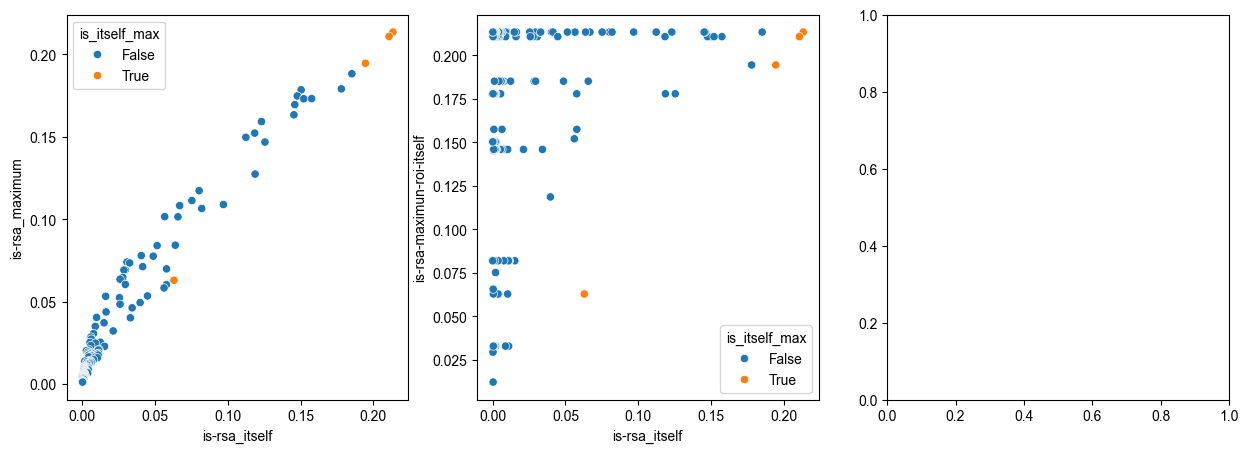

In [170]:

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5))
sns.scatterplot(data=df_maximun, x="is-rsa_itself", y="is-rsa_maximum", hue="is_itself_max", ax=ax1)


sns.scatterplot(data=df_maximun, x="is-rsa_itself", y="is-rsa-maximun-roi-itself", hue="is_itself_max", ax=ax2)







<Axes: xlabel='is-rsa_itself', ylabel='is-rsa_max_other'>

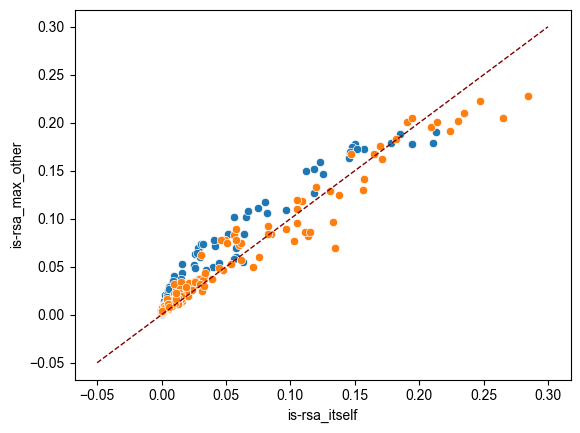

In [133]:
sns.scatterplot(data=df_merge, x="is-rsa_itself", y="is-rsa_max_other")

sns.scatterplot(data=df_merge, x="ws-rsa_itself", y="ws-rsa_max_other")
# Plot x=y
sns.lineplot(x=[-0.05, 0.3], y=[-0.05, 0.3], color='maroon', linestyle='--', lw=1)

In [294]:
df_connectivity = pd.read_parquet(filename_full_comparison)
df_connectivity = df_connectivity.query("subject_i != subject_j").groupby(["roi_x", "roi_y"]).similarity.mean()
df_connectivity = df_connectivity.reset_index()
filename_repetitions = derivatives_folder / "revision/rsa_reliability_isrsa_repetition_based-50.parquet"
df_reliability = pd.read_parquet(filename_repetitions).query("subject_i != subject_j")
df_reliability = df_reliability.groupby(["roi"]).similarity.describe()
# Move columns as 1 single level
df_reliability = df_reliability.reset_index()
df_reliability = df_reliability[["roi", "mean", "std"]]
df_reliability["relative_error"] = df_reliability["std"] / df_reliability["mean"]


rois = ['V1', 'V2', 'V3', 'V4', 
         'V8', 'V3A', 'V3B', 'V3CD', 'VVC', 
         'VMV3', 'VMV2', 'VMV1', 
         'PHA1', 'PHA2', 'PHA3',
         'IP0', 'PGp', 'DVT', 'LO3', 'LO2', 'PIT', 'LO1',
         'FFC', 'PH',
         'TPOJ3', 'V4t', 'FST', 'MST', 'MT', 'TPOJ2']
hcp = pd.read_csv(filename_hcp)

selected_rois = hcp.query("name in @rois").roi.tolist()
df_reliability = df_reliability.query("roi in @selected_rois")
df_connectivity = df_connectivity.query("roi_x in @selected_rois and roi_y in @selected_rois")


df_reliability["reliability"] = 1 / (1 + df_reliability["relative_error"]**2)
#df_reliability["reliability"] = df_reliability["mean"] ** 2 / (df_reliability["mean"] ** 2 + df_reliability["std"] ** 2)

df_reliability



,roi,mean,std,relative_error,reliability
0,1,0.194863,0.056315,0.288997,0.922918
1,2,0.210782,0.084063,0.398813,0.862774
3,4,0.178350,0.054047,0.303038,0.915892
4,5,0.125881,0.053526,0.425211,0.846881
5,6,0.118937,0.043533,0.366014,0.881860
6,7,0.096901,0.042078,0.434241,0.841351
12,13,0.063759,0.040955,0.642343,0.707912
17,18,0.062872,0.030868,0.490962,0.805773
18,19,0.075381,0.032158,0.426607,0.846028
19,20,0.039809,0.042291,1.062348,0.469796


# Noise normalization of connectivity matrices

In [ ]:
import numpy as np
import pandas as pd




df_corr = df_connectivity.copy()
df_corr = df_corr.merge(hcp[["roi", "name"]].rename(columns={"roi": "roi_x", "name": "name_x"}), left_on="roi_x", right_on="roi_x")
df_corr = df_corr.merge(hcp[["roi", "name"]].rename(columns={"roi": "roi_y", "name": "name_y"}), left_on="roi_y", right_on="roi_y")

df_corr = df_corr.merge(df_corr.query("roi_x == roi_y")[["roi_x", "similarity"]].rename(columns={"similarity": "self_similarity_x"}), on="roi_x")

df_corr = df_corr.merge(df_corr.query("roi_x == roi_y")[["roi_y", "similarity"]].rename(columns={"similarity": "self_similarity_y"}), on="roi_y")

df_corr["similarity_normalized"] = df_corr["similarity"] / np.sqrt(df_corr["self_similarity_x"] * df_corr["self_similarity_y"])


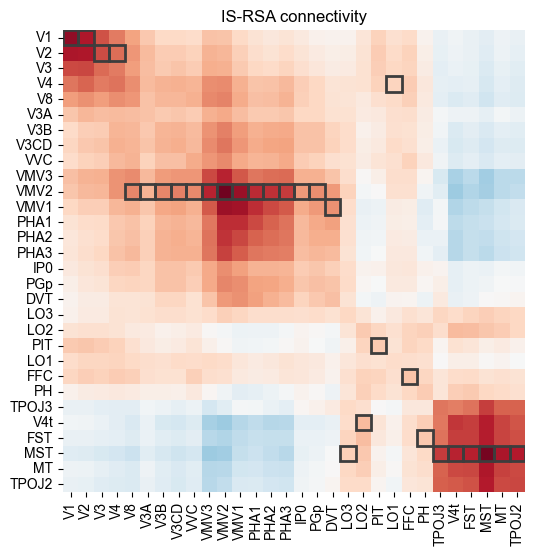

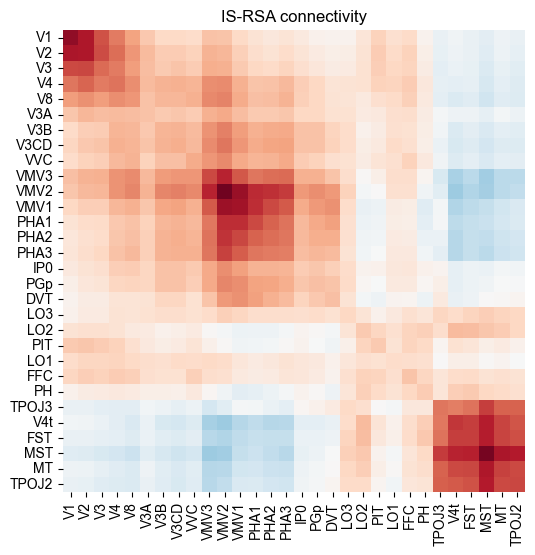

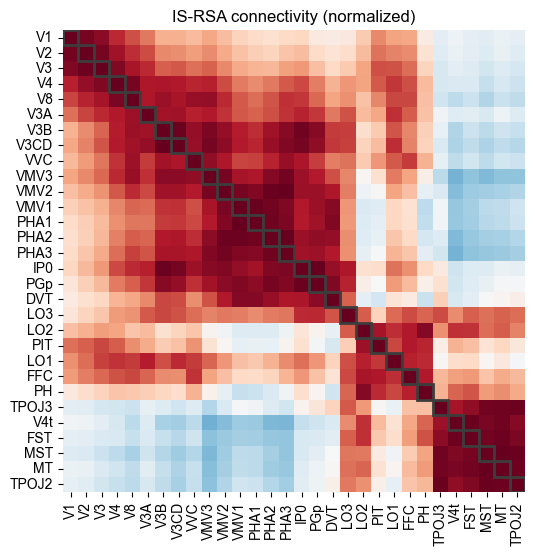

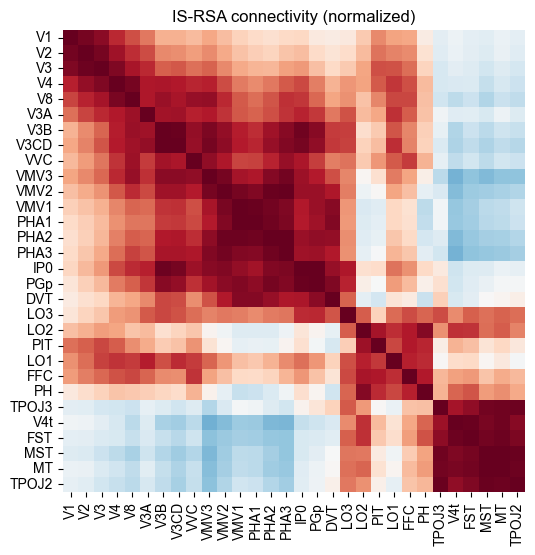

In [390]:


for normalize in [False, True]:
    values = "similarity_normalized" if normalize else "similarity"
    vmax = 1 if normalize else 0.22
    
    rho_matrix = df_corr.pivot(index="name_x", columns="name_y", values=values)
    rho_matrix = rho_matrix.loc[rois, rois]
    rho_matrix
    for squares in [True, False]:

        fig, ax = plt.subplots(figsize=(6, 6))
        sns.heatmap(rho_matrix, cmap="RdBu_r", center=0, ax=ax, vmin=-vmax, vmax=vmax, cbar=False, square=True)
        ax.set_xlabel("")
        ax.set_ylabel("")
        title = "IS-RSA connectivity" if not normalize else "IS-RSA connectivity (normalized)"
        ax.set_title(title)

        if squares:
            for i, col in enumerate(rho_matrix.columns):
                max_row = rho_matrix[col].idxmax()
                j = rho_matrix.index.get_loc(max_row)
                if normalize: j = i
                ax.add_patch(plt.Rectangle((i, j), 1, 1, fill=False, edgecolor=(0.24, 0.24, 0.24), lw=2))

        suffix = "-squares" if squares else ""
        norm_suffix = "-normalized" if normalize else ""
        fig.savefig(output_folder / f"reviewer2-comment4-isrsa-connectivity{norm_suffix}{suffix}.pdf", transparent=True, bbox_inches="tight")

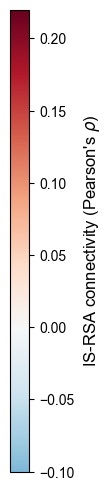

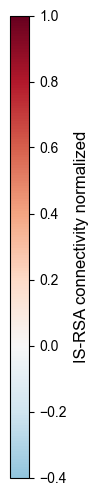

In [376]:
fig_cbar, ax_cbar = plot_cbar(
cmap="RdBu_r",
title=r"IS-RSA connectivity (Pearson's $\rho$)",
vmin=-0.22,
vmax=0.22,
locator=0.05,
horizontal=False,
rotation=90,
labelpad=5,
figsize=(0.25, 6),
percent=False,
)
ax_cbar.set_ylim(-0.1, 0.22)
fig_cbar.savefig(output_folder / "reviewer2-comment4-isrsa-connectivity-cbar.pdf", transparent=True, bbox_inches="tight")


fig_cbar, ax_cbar = plot_cbar(
cmap="RdBu_r",
title=r"IS-RSA connectivity normalized",
vmin=-1,
vmax=1,
locator=0.2,
horizontal=False,
rotation=90,
labelpad=5,
figsize=(0.25, 6),
percent=False,
)
ax_cbar.set_ylim(-0.4, 1)
fig_cbar.savefig(output_folder / "reviewer2-comment4-isrsa-connectivity-cbar-normalized.pdf", transparent=True, bbox_inches="tight")